# Basic Data Exploration

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from lana_nlp.analysis.lyrics_analyzer import LyricsAnalyzer
from lana_nlp.analysis.vocabulary import VocabularyAnalyzer

In [2]:
df = pd.read_csv("../data/processed/lyrics.csv")

In [3]:
analyzer = LyricsAnalyzer(
    df,
    basic_text_column="basic_cleaned_lyrics",
    nlp_text_column="nlp_cleaned_lyrics",
)

df = analyzer.analyze()

In [4]:
df.shape

(154, 13)

In [5]:
df["album"].value_counts()

album
Ultraviolence                                          16
Lust for Life                                          16
Did You Know That There's a Tunnel Under Ocean Blvd    16
Sirens                                                 15
Born To Die                                            15
Blue Banisters                                         15
Honeymoon                                              14
Norman Fucking Rockwell!                               14
Lana Del Ray, A.K.A. Lizzy Grant                       13
Chemtrails Over the Country Club                       11
Paradise                                                9
Name: count, dtype: int64

In [6]:
print(f"Min Year: {df['year'].min()}")
print(f"Max Year: {df['year'].max()}")

Min Year: 2006
Max Year: 2023


In [7]:
df.columns.tolist()

['Unnamed: 0',
 'artist',
 'album',
 'song',
 'year',
 'lyrics',
 'basic_cleaned_lyrics',
 'nlp_cleaned_lyrics',
 'word_count',
 'unique_words',
 'syllable_count',
 'line_count',
 'reading_minutes']

## Album Statistics

In [8]:
album_summary = analyzer.statistics.summary_by_album()
# album_summary.head(11)

album_summary.sort_values(
    "avg_words",
    ascending=False
)

,songs,avg_words,median_words,min_words,max_words,total_words,avg_reading_minutes
album,,,,,,,
Born To Die,15,403.866667,395.0,254,600,6058,2.019333
Did You Know That There's a Tunnel Under Ocean Blvd,16,377.437500,338.5,188,749,6039,1.887188
Lust for Life,16,357.562500,354.0,207,613,5721,1.787813
Norman Fucking Rockwell!,14,332.285714,313.0,196,478,4652,1.661429
Chemtrails Over the Country Club,11,310.545455,317.0,171,402,3416,1.552727
Blue Banisters,15,279.266667,293.0,0,436,4189,1.396333
Paradise,9,277.777778,290.0,90,408,2500,1.388889
Ultraviolence,16,273.062500,263.5,126,395,4369,1.365312
Honeymoon,14,270.285714,270.0,84,411,3784,1.351429


In [9]:
album_summary.columns.tolist()

['songs',
 'avg_words',
 'median_words',
 'min_words',
 'max_words',
 'total_words',
 'avg_reading_minutes']

## Average Words per Song by Album

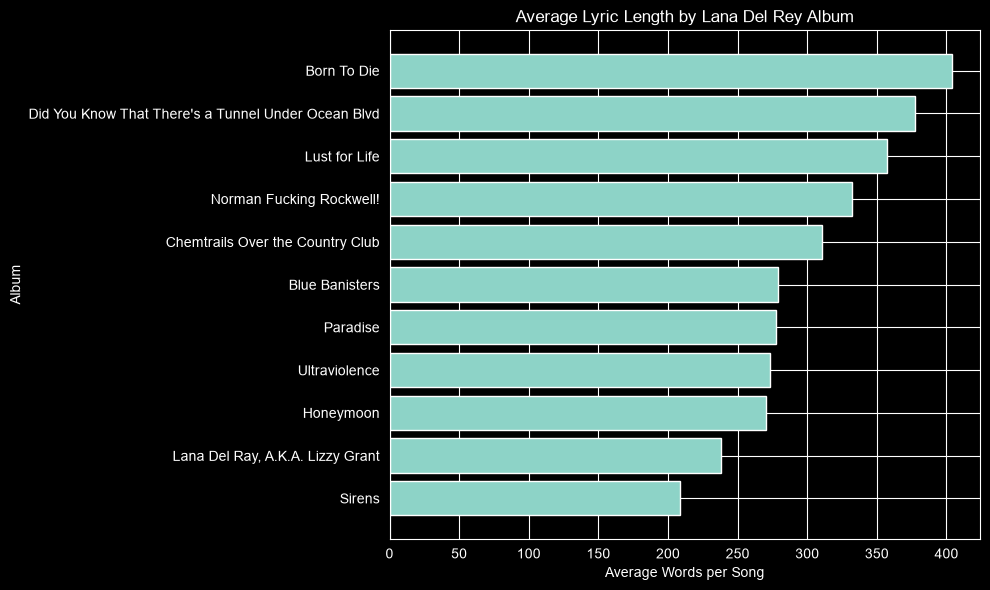

In [10]:
album_words = album_summary.sort_values("avg_words")

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    album_words.index,
    album_words["avg_words"]
)

plt.xlabel("Average Words per Song")
plt.ylabel("Album")
plt.title("Average Lyric Length by Lana Del Rey Album")

plt.tight_layout()
plt.show()

## Average Words per Album Over Time

In [11]:
album_years = (
    df.groupby("album")["year"]
    .min()
)

album_summary["year"] = album_years

chronological = album_summary.sort_values("year")

chronological[["year", "avg_words"]]

,year,avg_words
album,,
Sirens,2006,208.733333
"Lana Del Ray, A.K.A. Lizzy Grant",2010,238.230769
Paradise,2012,277.777778
Born To Die,2012,403.866667
Ultraviolence,2014,273.062500
Honeymoon,2015,270.285714
Lust for Life,2016,357.562500
Norman Fucking Rockwell!,2019,332.285714
Chemtrails Over the Country Club,2021,310.545455


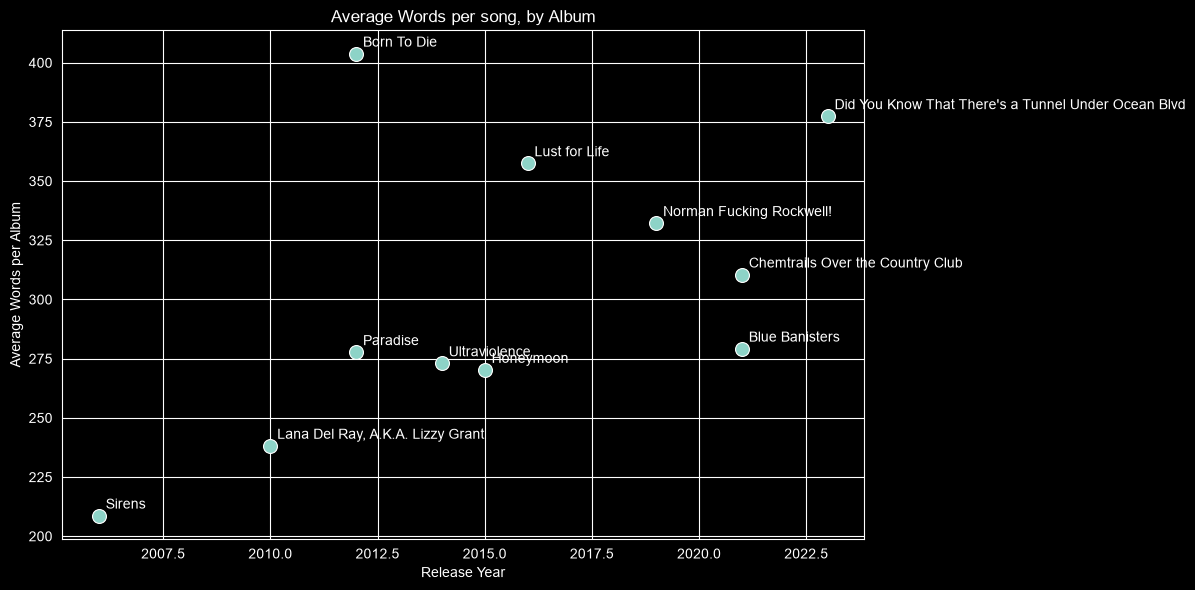

In [12]:
plt.figure(
    figsize=(12, 6)
)

sns.scatterplot(
    data=chronological,
    x="year",
    y="avg_words",
    s=100
)

for album, row in chronological.iterrows():
    plt.annotate(
        album,
        (row["year"], row["avg_words"]),
        xytext=(5,5),
        textcoords="offset points"
    )

plt.xlabel("Release Year")
plt.ylabel("Average Words per Album")
plt.title("Average Words per song, by Album")

plt.tight_layout()
plt.show()

Average lyrical length increased across Lana Del Rey's discography. Born To Die looks like it could be an outlier.


## Does Born To Die have wordier lyric sections in general?

This would be in comparison to albums that were made around the same time period (Paradise, Ultraviolence, and Honeymoon). All of these had significantly less average words per song than Born To Die.


In [13]:
# Calculate words per line column
df["words_per_line"] = (
    df["word_count"] / df["line_count"].replace(0, pd.NA)
)

df.groupby("album")["words_per_line"].mean().sort_values()

album
Paradise                                               5.583152
Lana Del Ray, A.K.A. Lizzy Grant                         5.7268
Lust for Life                                          6.057829
Blue Banisters                                         6.091362
Ultraviolence                                           6.11597
Did You Know That There's a Tunnel Under Ocean Blvd    6.123504
Honeymoon                                              6.136474
Chemtrails Over the Country Club                       6.167297
Norman Fucking Rockwell!                               6.499715
Sirens                                                 6.745097
Born To Die                                            7.159159
Name: words_per_line, dtype: object

Born To Die does appear to be wordier, but this may not be the best statistic to see what is happening with this album. For example, Lust for Life had a high average word count, but is one of the least wordy albums (based on word count / line count).

## Lexical Diversity over Time

<Axes: xlabel='year', ylabel='lexical_diversity'>

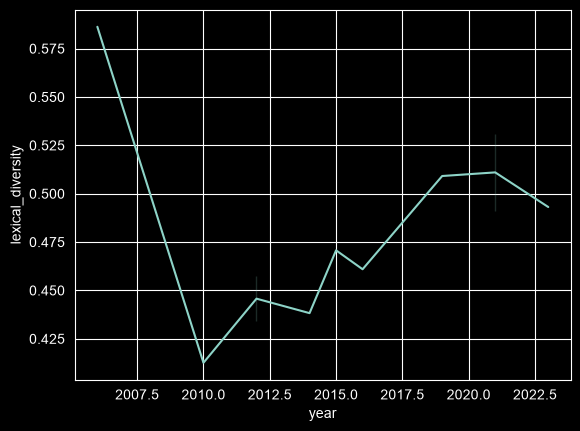

In [23]:
df["lexical_diversity"] = df["nlp_cleaned_lyrics"].apply(
    lambda lyrics: VocabularyAnalyzer(
        pd.DataFrame({"lyrics": [lyrics]}),
    ).lexical_diversity()
)

album_lexical_diversity = (
    df.groupby(["album", "year"])["lexical_diversity"]
      .mean()
      .reset_index()
      .sort_values("year")
)

sns.lineplot(
    data=album_lexical_diversity,
    x="year",
    y="lexical_diversity",
    markers='o'
)